### Prepare Data for Player Embeddings

In [55]:
import sys
from pathlib import Path

# Regarding Tennis_ML_Project/Notebooks, scr is a sibbling, not a child, 
# so we need to add the parent of Notebooks to the path so that we can import from src

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))


In [56]:
import pandas as pd
import torch
from torch.utils.data import DataLoader

from src.dataset import build_player_id_mapping, add_player_ids, TennisMatchDatasetWithPlayers


In [57]:
matches = pd.read_csv("../Data/processed/matches_with_players_clusters.csv")
matches.drop(columns=["winner_id", "loser_id"], inplace=True)  # Remove old player ID columns if they exist
matches.head()


,year,tourney_date,surface,tourney_level,winner_name,winner_rank,winner_age,winner_ht,loser_name,loser_rank,...,w_ace,w_df,w_bpSaved,w_bpFaced,l_ace,l_df,l_bpSaved,l_bpFaced,winner_cluster,loser_cluster
0,2018,20180101,Hard,A,Ryan Harrison,47.0,25.6,185.0,Leonardo Mayer,52.0,...,9.0,2.0,8.0,9.0,10.0,3.0,1.0,4.0,4,4
1,2018,20180101,Hard,A,Jared Donaldson,54.0,21.2,188.0,Jordan Thompson,94.0,...,5.0,3.0,4.0,5.0,3.0,5.0,7.0,11.0,4,3
2,2018,20180101,Hard,A,Denis Istomin,63.0,31.3,185.0,Damir Dzumhur,30.0,...,7.0,0.0,9.0,11.0,8.0,6.0,10.0,16.0,1,3
3,2018,20180101,Hard,A,Alex De Minaur,208.0,18.8,183.0,Steve Johnson,44.0,...,9.0,3.0,2.0,3.0,6.0,2.0,4.0,6.0,0,4
4,2018,20180101,Hard,A,Michael Mmoh,175.0,19.9,188.0,Federico Delbonis,68.0,...,5.0,4.0,3.0,3.0,4.0,0.0,0.0,2.0,4,1


#### Build Player Mapping

In [58]:
player_to_id, id_to_player = build_player_id_mapping(matches)

num_players = len(player_to_id)
print(f"Number of players with embeddings: {num_players}")


Number of players with embeddings: 924


In [59]:
matches = add_player_ids(matches, player_to_id)

matches[["winner_name", "winner_id", "loser_name", "loser_id"]].head()
# matches_a = matches[matches["winner_name"] == "Alex De Minaur"]
# matches_a[["winner_name", "winner_id", "loser_name", "loser_id"]].head()


,winner_name,winner_id,loser_name,loser_id
0,Ryan Harrison,0,Leonardo Mayer,55
1,Jared Donaldson,1,Jordan Thompson,258
2,Denis Istomin,2,Damir Dzumhur,56
3,Alex De Minaur,3,Steve Johnson,51
4,Michael Mmoh,4,Federico Delbonis,176


In [60]:
matches[["winner_name", "winner_id", "loser_name", "loser_id"]].isna().sum()

winner_name    0
winner_id      0
loser_name     0
loser_id       0
dtype: int64

In [61]:
matches.columns

Index(['year', 'tourney_date', 'surface', 'tourney_level', 'winner_name',
       'winner_rank', 'winner_age', 'winner_ht', 'loser_name', 'loser_rank',
       'loser_age', 'loser_ht', 'w_ace', 'w_df', 'w_bpSaved', 'w_bpFaced',
       'l_ace', 'l_df', 'l_bpSaved', 'l_bpFaced', 'winner_cluster',
       'loser_cluster', 'winner_id', 'loser_id'],
      dtype='object')

At this point, every player has a stable ID, mapping is reusable, no leakage, ready for embeddings

#### Build Match-Level Features

In [62]:
import numpy as np

def build_match_dataset(matches):
    rows = []

    for _, row in matches.iterrows():
        # winner vs loser
        rows.append({
            "winner_id": row["winner_id"],
            "loser_id": row["loser_id"],
            "rank_diff": row["winner_rank"] - row["loser_rank"],
            "age_diff": row["winner_age"] - row["loser_age"],
            "height_diff": row["winner_ht"] - row["loser_ht"],
            "cluster_diff": row["winner_cluster"] - row["loser_cluster"],
            "surface": row["surface"],
            "tourney_level": row["tourney_level"],
            "target": 1
        })
        
        # loser vs winner
        rows.append({
            "winner_id": row["loser_id"],
            "loser_id": row["winner_id"],
            "rank_diff": row["loser_rank"] - row["winner_rank"],
            "age_diff": row["loser_age"] - row["winner_age"],
            "height_diff": row["loser_ht"] - row["winner_ht"],
            "cluster_diff": row["loser_cluster"] - row["winner_cluster"],
            "surface": row["surface"],
            "tourney_level": row["tourney_level"],
            "target": 0
        })
    
    return pd.DataFrame(rows)

dataset = build_match_dataset(matches)

print(dataset.shape)
dataset.head()


(37754, 9)


,winner_id,loser_id,rank_diff,age_diff,height_diff,cluster_diff,surface,tourney_level,target
0,0,55,-5.0,-5.0,-3.0,0,Hard,A,1
1,55,0,5.0,5.0,3.0,0,Hard,A,0
2,1,258,-40.0,-2.5,5.0,1,Hard,A,1
3,258,1,40.0,2.5,-5.0,-1,Hard,A,0
4,2,56,33.0,5.7,10.0,-2,Hard,A,1


### Extend the PyTorch Dataset to Support Player IDs

#### Create Datasets

#### Time Split

In [63]:
train_matches = matches[matches["year"] <= 2022]
val_matches = matches[matches["year"] == 2023]
test_matches = matches[matches["year"] == 2024]

train_data = build_match_dataset(train_matches)
val_data = build_match_dataset(val_matches)
test_data = build_match_dataset(test_matches)

print(train_data.shape, val_data.shape, test_data.shape)

(25630, 9) (5972, 9) (6152, 9)


#### Handle Missing Values

In [64]:
from sklearn.impute import SimpleImputer

# Even though we don't have missing values in cluster_diff, we include it here for consistency
# The imputer does nothing to this column
numeric_features = ["rank_diff", "age_diff", "height_diff", "cluster_diff"]
categorical_features = ["surface", "tourney_level"]
target_col = "target"

num_imputer = SimpleImputer(strategy="median")

train_data[numeric_features] = num_imputer.fit_transform(train_data[numeric_features])
val_data[numeric_features] = num_imputer.transform(val_data[numeric_features])
test_data[numeric_features] = num_imputer.transform(test_data[numeric_features])


In [65]:
cat_imputer = SimpleImputer(strategy="most_frequent")

train_data[["surface"]] = cat_imputer.fit_transform(train_data[["surface"]])
val_data[["surface"]] = cat_imputer.transform(val_data[["surface"]])
test_data[["surface"]] = cat_imputer.transform(test_data[["surface"]])


In [66]:
print(train_data.isna().sum())
print(val_data.isna().sum())
print(test_data.isna().sum())


winner_id        0
loser_id         0
rank_diff        0
age_diff         0
height_diff      0
cluster_diff     0
surface          0
tourney_level    0
target           0
dtype: int64
winner_id        0
loser_id         0
rank_diff        0
age_diff         0
height_diff      0
cluster_diff     0
surface          0
tourney_level    0
target           0
dtype: int64
winner_id        0
loser_id         0
rank_diff        0
age_diff         0
height_diff      0
cluster_diff     0
surface          0
tourney_level    0
target           0
dtype: int64


#### Extract X / y from Splits

In [67]:
X_train = train_data[numeric_features + categorical_features]
X_val   = val_data[numeric_features + categorical_features]
X_test  = test_data[numeric_features + categorical_features]

y_train = train_data[target_col].values
y_val   = val_data[target_col].values
y_test  = test_data[target_col].values



#### Encode Categoricals (OneHot)

In [68]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[categorical_features])
X_val_cat   = encoder.transform(X_val[categorical_features])
X_test_cat  = encoder.transform(X_test[categorical_features])


#### Scale Numeric Features

In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[numeric_features])
X_val_num   = scaler.transform(X_val[numeric_features])
X_test_num  = scaler.transform(X_test[numeric_features])


In [70]:
print(X_train_num.shape, X_train_cat.shape)
print(X_val_num.shape, X_val_cat.shape)
print(X_test_num.shape, X_test_cat.shape)


(25630, 4) (25630, 8)
(5972, 4) (5972, 8)
(6152, 4) (6152, 8)


#### Extract Player IDs

In [71]:
winner_ids_train = train_data["winner_id"].values
loser_ids_train  = train_data["loser_id"].values

winner_ids_val = val_data["winner_id"].values
loser_ids_val  = val_data["loser_id"].values

winner_ids_test = test_data["winner_id"].values
loser_ids_test  = test_data["loser_id"].values


#### Create Datasets and DataLoaders

In [72]:
train_dataset = TennisMatchDatasetWithPlayers(
    X_train_num,
    X_train_cat,
    winner_ids_train,
    loser_ids_train,
    y_train
)

print(type(train_dataset.y))


val_dataset = TennisMatchDatasetWithPlayers(
    X_val_num,
    X_val_cat,
    winner_ids_val,
    loser_ids_val,
    y_val
)

print(type(val_dataset.y))

test_dataset = TennisMatchDatasetWithPlayers(
    X_test_num,
    X_test_cat,
    winner_ids_test,
    loser_ids_test,
    y_test
)


<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [73]:
type(y_train)


numpy.ndarray

In [74]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(train_loader)


In [75]:
batch = next(iter(train_loader))

for tensor in batch:
    print(tensor.shape, tensor.dtype)


torch.Size([64, 4]) torch.float32
torch.Size([64, 8]) torch.float32
torch.Size([64]) torch.int64
torch.Size([64]) torch.int64
torch.Size([64]) torch.float32


### New Model

In [76]:
from src.models import MatchOutcomeNNWithEmbeddings


#### Model

In [77]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MatchOutcomeNNWithEmbeddings(
    num_numeric_features=X_train_num.shape[1],
    num_categorical_features=X_train_cat.shape[1],
    num_players=num_players,
    embedding_dim=8,
    hidden_dim=32,
    dropout=0.3
).to(device)

model

MatchOutcomeNNWithEmbeddings(
  (player_embedding): Embedding(924, 8)
  (network): Sequential(
    (0): Linear(in_features=20, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.15, inplace=False)
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

#### Loss and Optimizer

In [78]:
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


### Training Loop

In [79]:
for x_num, x_cat, winner_id, loser_id, y in train_loader:
    x_num = x_num.to(device)
    x_cat = x_cat.to(device)
    winner_id = winner_id.to(device)
    loser_id = loser_id.to(device)
    y = y.to(device)

    optimizer.zero_grad()

    logits = model(
        x_num,
        x_cat,
        winner_id,
        loser_id
    )

    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()



In [80]:
model.eval()

with torch.no_grad():
    batch = next(iter(train_loader))
    x_num, x_cat, w_id, l_id, y = batch

    preds = model(
        x_num.to(device),
        x_cat.to(device),
        w_id.to(device),
        l_id.to(device)
    )

print(preds.shape)


torch.Size([64])


### Train & Evaluate the Embedding Model

* Training loop (with AUC tracking)
* Validation + early stopping
* Final test evaluation (2024)

#### Training Loop (Embedding Model)

In [81]:
from sklearn.metrics import roc_auc_score, accuracy_score
import numpy as np


In [82]:
def train_embedding_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    n_epochs=20,
    device="cpu"
):
    best_val_auc = 0.0
    best_state = None

    for epoch in range(1, n_epochs + 1):
        # -------- TRAIN --------
        model.train()
        train_losses = []

        for x_num, x_cat, w_id, l_id, y in train_loader:
            x_num = x_num.to(device)
            x_cat = x_cat.to(device)
            w_id = w_id.to(device)
            l_id = l_id.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(x_num, x_cat, w_id, l_id)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        # -------- VALIDATION --------
        model.eval()
        val_preds = []
        val_targets = []

        with torch.no_grad():
            for x_num, x_cat, w_id, l_id, y in val_loader:
                x_num = x_num.to(device)
                x_cat = x_cat.to(device)
                w_id = w_id.to(device)
                l_id = l_id.to(device)

                logits = model(x_num, x_cat, w_id, l_id)
                probs = torch.sigmoid(logits)

                val_preds.extend(probs.cpu().numpy())
                val_targets.extend(y.numpy())

        val_auc = roc_auc_score(val_targets, val_preds)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = model.state_dict()

        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {np.mean(train_losses):.4f} | "
            f"Val AUC: {val_auc:.4f}"
        )

    model.load_state_dict(best_state)
    print(f"\nBest Validation AUC: {best_val_auc:.4f}")
    return model


### Train the Model

In [83]:
model = train_embedding_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    n_epochs=20,
    device=device
)


Epoch 01 | Train Loss: 0.6504 | Val AUC: 0.6771
Epoch 02 | Train Loss: 0.6439 | Val AUC: 0.6790
Epoch 03 | Train Loss: 0.6374 | Val AUC: 0.6802
Epoch 04 | Train Loss: 0.6313 | Val AUC: 0.6781
Epoch 05 | Train Loss: 0.6261 | Val AUC: 0.6778
Epoch 06 | Train Loss: 0.6205 | Val AUC: 0.6778
Epoch 07 | Train Loss: 0.6151 | Val AUC: 0.6760
Epoch 08 | Train Loss: 0.6104 | Val AUC: 0.6750
Epoch 09 | Train Loss: 0.6058 | Val AUC: 0.6720
Epoch 10 | Train Loss: 0.6027 | Val AUC: 0.6692
Epoch 11 | Train Loss: 0.5994 | Val AUC: 0.6688
Epoch 12 | Train Loss: 0.5978 | Val AUC: 0.6680
Epoch 13 | Train Loss: 0.5945 | Val AUC: 0.6660
Epoch 14 | Train Loss: 0.5948 | Val AUC: 0.6637
Epoch 15 | Train Loss: 0.5916 | Val AUC: 0.6630
Epoch 16 | Train Loss: 0.5893 | Val AUC: 0.6612
Epoch 17 | Train Loss: 0.5879 | Val AUC: 0.6601
Epoch 18 | Train Loss: 0.5865 | Val AUC: 0.6582
Epoch 19 | Train Loss: 0.5863 | Val AUC: 0.6585
Epoch 20 | Train Loss: 0.5852 | Val AUC: 0.6575

Best Validation AUC: 0.6802


### Final Evaluation on Test Set (2024)

In [84]:
model.eval()

test_preds = []
test_targets = []

with torch.no_grad():
    for x_num, x_cat, w_id, l_id, y in test_loader:
        x_num = x_num.to(device)
        x_cat = x_cat.to(device)
        w_id = w_id.to(device)
        l_id = l_id.to(device)

        logits = model(x_num, x_cat, w_id, l_id)
        probs = torch.sigmoid(logits)

        test_preds.extend(probs.cpu().numpy())
        test_targets.extend(y.numpy())


In [85]:
test_auc = roc_auc_score(test_targets, test_preds)
test_acc = accuracy_score(
    test_targets,
    (np.array(test_preds) >= 0.5).astype(int)
)

print(f"Embedding NN Test Accuracy (2024): {test_acc:.4f}")
print(f"Embedding NN Test ROC-AUC (2024): {test_auc:.4f}")


Embedding NN Test Accuracy (2024): 0.6174
Embedding NN Test ROC-AUC (2024): 0.6480


The embedding model is learning something that does not transfer to future players/matches.

Root cause: Player embeddings are too powerful for the data size. Even with embedding_dim = 8, that’s thousands of free parameters that:
* memorize player identities
* absorb signal already present in rank_diff
* overfit historical dominance patterns
* break temporal generalization

The pattern:
* 📉 Train loss keeps decreasing
* 📉 Val AUC peaks early (epoch 2–3)
* 📉 Val AUC steadily degrades

That is textbook overfitting.

#### The baseline NN beat embeddings
Your earlier NN used:
* rank_diff
* age_diff
* height_diff
* cluster_diff
* surface, tourney_level

These are stable, causal-ish signals.

Embeddings added:
* identity leakage
* historical bias
* temporal fragility

So the simpler model wins

#### Final Interpretation
Player embeddings were explored but resulted in overfitting due to strong identity leakage and limited temporal generalization. A feature-based neural network generalized better.

One possible light fix (we are not going to do it):
* embedding_dim = 4
* freeze embeddings after 3 epochs
* higher dropout on embedding branch

## Player Embeddings Analysis

We are going to study what did the model learn about players, even if it didn’t improve accuracy

#### Extract the embedding matrix

In [86]:
import torch
import pandas as pd
import numpy as np


In [87]:
model.eval()

# Extract embedding weights
embedding_weights = model.player_embedding.weight.detach().cpu().numpy()

print(embedding_weights.shape)


(924, 8)


#### Attach player names

In [88]:
player_to_id
id_to_player


{0: 'Ryan Harrison',
 1: 'Jared Donaldson',
 2: 'Denis Istomin',
 3: 'Alex De Minaur',
 4: 'Michael Mmoh',
 5: 'Mischa Zverev',
 6: 'Alexandr Dolgopolov',
 7: 'Horacio Zeballos',
 8: 'Matthew Ebden',
 9: 'Hyeon Chung',
 10: 'Kyle Edmund',
 11: 'John Millman',
 12: 'Nick Kyrgios',
 13: 'Grigor Dimitrov',
 14: 'Borna Coric',
 15: 'Nikoloz Basilashvili',
 16: 'Andrey Rublev',
 17: 'Fernando Verdasco',
 18: 'Guido Pella',
 19: 'Stefano Travaglia',
 20: 'Mirza Basic',
 21: 'Feliciano Lopez',
 22: 'Peter Gojowczyk',
 23: 'Matteo Berrettini',
 24: 'Gael Monfils',
 25: 'Jan Lennard Struff',
 26: 'Richard Gasquet',
 27: 'Stefanos Tsitsipas',
 28: 'Aljaz Bedene',
 29: 'Dominic Thiem',
 30: 'Thiago Monteiro',
 31: 'Laslo Djere',
 32: 'Mikhail Kukushkin',
 33: 'Marton Fucsovics',
 34: 'Nicolas Jarry',
 35: 'Robin Haase',
 36: 'Ricardo Ojeda Lara',
 37: 'Ilya Ivashka',
 38: 'Gilles Simon',
 39: 'Pierre Hugues Herbert',
 40: 'Yuki Bhambri',
 41: 'Ramkumar Ramanathan',
 42: 'Kevin Anderson',
 43: 'Be

In [89]:
embedding_df = pd.DataFrame(
    embedding_weights,
    columns=[f"emb_{i}" for i in range(embedding_weights.shape[1])]
)

embedding_df["player_id"] = embedding_df.index
embedding_df["player_name"] = embedding_df["player_id"].map(id_to_player)

embedding_df.head()


,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,player_id,player_name
0,-0.327618,-0.336032,-0.984709,-0.688059,1.324461,2.423643,0.685487,-0.534224,0,Ryan Harrison
1,-1.168340,0.548394,0.576854,-0.479112,0.318551,-1.315999,-0.708217,-0.056936,1,Jared Donaldson
2,-0.286345,-1.418902,-0.626814,0.849347,-0.265382,0.642354,-0.624226,-0.334727,2,Denis Istomin
3,-0.030270,-1.234759,0.464095,-1.663151,1.059946,1.583550,0.782595,1.700808,3,Alex De Minaur
4,-1.639731,0.734423,1.232867,0.401711,-0.207665,0.568423,-1.098003,-1.252770,4,Michael Mmoh


#### Dimensionality reduction (PCA)

In [90]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
emb_2d = pca.fit_transform(embedding_weights)

embedding_df["pca_1"] = emb_2d[:, 0]
embedding_df["pca_2"] = emb_2d[:, 1]

print("Explained variance:", pca.explained_variance_ratio_)


Explained variance: [0.19166216 0.13603316]


#### Visualization

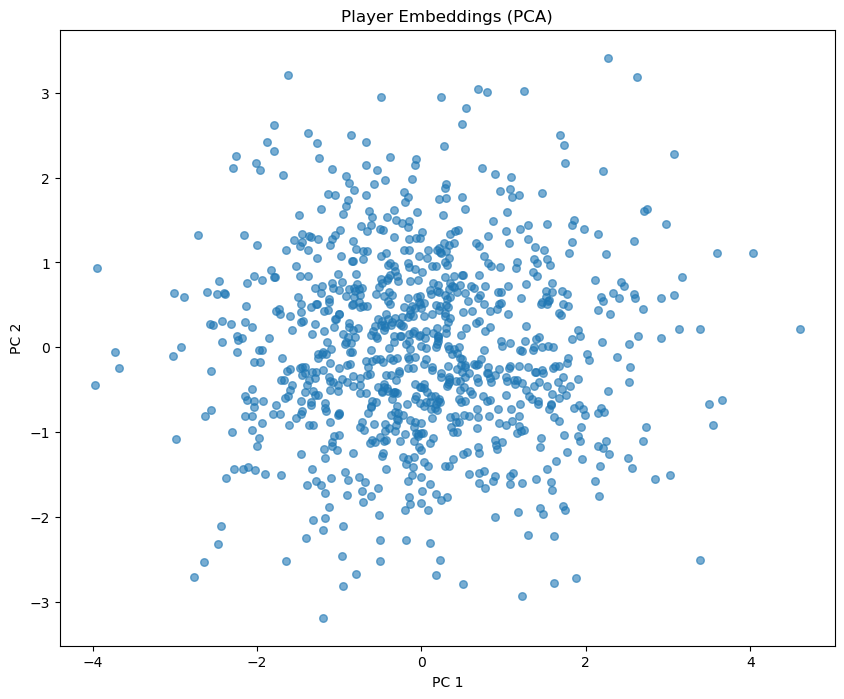

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(
    embedding_df["pca_1"],
    embedding_df["pca_2"],
    alpha=0.6,
    s=30
)
plt.title("Player Embeddings (PCA)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()


The embedding space is continuous rather than clustered, suggesting that player strength and characteristics lie on smooth gradients rather than discrete groups. Why this is expected?
Player embeddings here are:
* learned implicitly from match outcomes
* low-signal (tennis matches are noisy)
* contextual (rank, surface, opponent, etc.)

#### Inspect nearest neighbors

In [92]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embedding_weights)

def most_similar_players(player_name, top_k=5):
    pid = player_to_id[player_name]
    sims = similarity[pid]
    top_ids = np.argsort(sims)[::-1][1:top_k+1]
    return embedding_df.loc[top_ids, ["player_name"]]


In [93]:
most_similar_players("Rafael Nadal", top_k=5)


,player_name
54,Juan Martin del Potro
338,Philip Henning
107,M Abid Ali Khan Akbar
81,Novak Djokovic
555,Gustavo Heide


Coherent names:
* Del Potro ✅ (same era, power baseline player)
* Djokovic ✅ (elite rival, similar competitive profile)

The other three names don't represent a bug. Some lower-ranked players appear close in embedding space due to limited data and similar outcome patterns, highlighting both the power and limitations of learned representations in sparse regimes.

#### Compare with your clusters

In [94]:
player_clusters = matches[["winner_name", "winner_cluster"]].drop_duplicates()
player_clusters.columns = ["player_name", "cluster"]

embedding_df = embedding_df.merge(
    player_clusters,
    on="player_name",
    how="left"
)


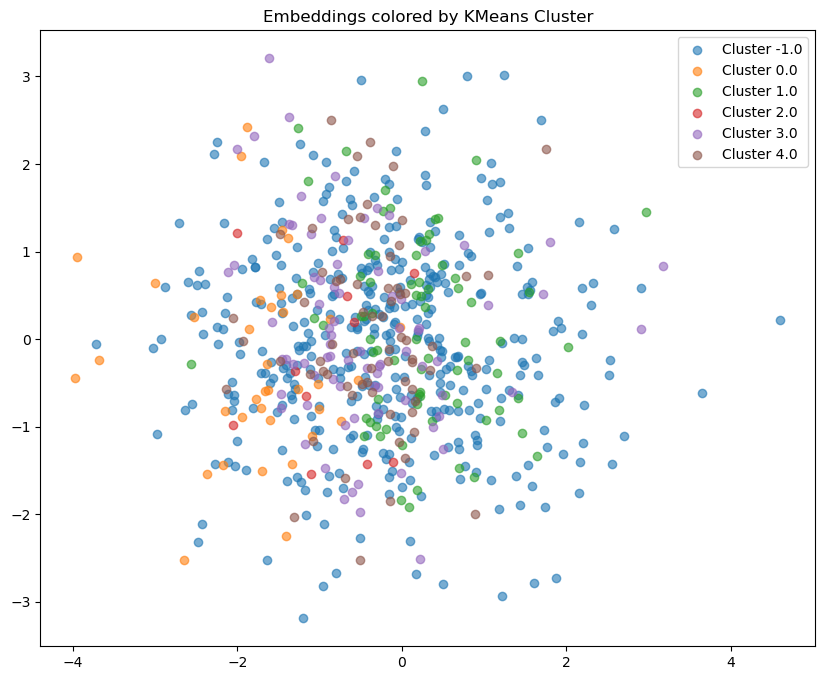

In [95]:
plt.figure(figsize=(10, 8))
for c in sorted(embedding_df["cluster"].dropna().unique()):
    subset = embedding_df[embedding_df["cluster"] == c]
    plt.scatter(subset["pca_1"], subset["pca_2"], label=f"Cluster {c}", alpha=0.6)

plt.legend()
plt.title("Embeddings colored by KMeans Cluster")
plt.show()


This plot shows:
* Heavy overlap between colors
* No clean separation by cluster label

This tells us something very interesting:
* KMeans clusters were built from aggregated statistics
* Embeddings are learned from pairwise interactions
* These represent different notions of similarity

In other words:
* Clustering = static player profile
* Embeddings = how players behave relative to others

Learned embeddings capture relational information that is not fully explained by static clustering features, suggesting complementary representations of player similarity.